In [1]:
import pandas as pd

df = pd.read_csv("data/player_game_logs_2025_26.csv")

In [ ]:
print(df.shape)

print(df.head())

print(df.info())

print(df.describe())

print(df.isnull().sum())

(26651, 72)
  SEASON_YEAR  PLAYER_ID     PLAYER_NAME  NICKNAME     TEAM_ID  \
0     2025-26    1642948   Ryan Nembhard      Ryan  1610612742   
1     2025-26    1642852     Derik Queen     Derik  1610612740   
2     2025-26    1630567  Scottie Barnes   Scottie  1610612761   
3     2025-26    1642847  Jeremiah Fears  Jeremiah  1610612740   
4     2025-26    1642866   Joan Beringer      Joan  1610612750   

  TEAM_ABBREVIATION               TEAM_NAME   GAME_ID            GAME_DATE  \
0               DAL        Dallas Mavericks  22501193  2026-04-12T00:00:00   
1               NOP    New Orleans Pelicans  22501195  2026-04-12T00:00:00   
2               TOR         Toronto Raptors  22501192  2026-04-12T00:00:00   
3               NOP    New Orleans Pelicans  22501195  2026-04-12T00:00:00   
4               MIN  Minnesota Timberwolves  22501195  2026-04-12T00:00:00   

       MATCHUP  ... PTS_RANK  PLUS_MINUS_RANK  NBA_FANTASY_PTS_RANK  DD2_RANK  \
0  DAL vs. CHI  ...     6828             

In [3]:
print(df.columns.tolist())

['SEASON_YEAR', 'PLAYER_ID', 'PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS', 'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'FP_HIGH_SCORE', 'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK', 'FGM_RANK', 'FGA_RANK', 'FG_PCT_RANK', 'FG3M_RANK', 'FG3A_RANK', 'FG3_PCT_RANK', 'FTM_RANK', 'FTA_RANK', 'FT_PCT_RANK', 'OREB_RANK', 'DREB_RANK', 'REB_RANK', 'AST_RANK', 'TOV_RANK', 'STL_RANK', 'BLK_RANK', 'BLKA_RANK', 'PF_RANK', 'PFD_RANK', 'PTS_RANK', 'PLUS_MINUS_RANK', 'NBA_FANTASY_PTS_RANK', 'DD2_RANK', 'TD3_RANK', 'WNBA_FANTASY_PTS_RANK', 'FP_HIGH_SCORE_RANK', 'AVAILABLE_FLAG', 'MIN_SEC', 'TEAM_COUNT']


In [4]:
curry = df[df["PLAYER_NAME"] == "Stephen Curry"]

print(curry.head())

      SEASON_YEAR  PLAYER_ID    PLAYER_NAME NICKNAME     TEAM_ID  \
42        2025-26     201939  Stephen Curry  Stephen  1610612744   
420       2025-26     201939  Stephen Curry  Stephen  1610612744   
979       2025-26     201939  Stephen Curry  Stephen  1610612744   
1260      2025-26     201939  Stephen Curry  Stephen  1610612744   
10991     2025-26     201939  Stephen Curry  Stephen  1610612744   

      TEAM_ABBREVIATION              TEAM_NAME   GAME_ID            GAME_DATE  \
42                  GSW  Golden State Warriors  22501199  2026-04-12T00:00:00   
420                 GSW  Golden State Warriors  22501184  2026-04-10T00:00:00   
979                 GSW  Golden State Warriors  22501154  2026-04-07T00:00:00   
1260                GSW  Golden State Warriors  22501142  2026-04-05T00:00:00   
10991               GSW  Golden State Warriors  22500696  2026-01-30T00:00:00   

           MATCHUP  ... PTS_RANK  PLUS_MINUS_RANK  NBA_FANTASY_PTS_RANK  \
42       GSW @ LAC  ...     2

In [49]:
print(
    curry[
        [
            "GAME_DATE",
            "MATCHUP",
            "PTS",
            "REB",
            "AST",
            "FG_PCT",
            "FG3_PCT",
            "PLUS_MINUS",
            "FGA",
            "FG3A",
            "FTA",
            "TOV"
        ]
    ].head(10)
)

                 GAME_DATE      MATCHUP  PTS  REB  AST  FG_PCT  FG3_PCT  \
42     2026-04-12T00:00:00    GSW @ LAC   24    6    3   0.500    0.444   
420    2026-04-10T00:00:00    GSW @ SAC   11    3    5   0.375    0.333   
979    2026-04-07T00:00:00  GSW vs. SAC   17    5    2   0.417    0.364   
1260   2026-04-05T00:00:00  GSW vs. HOU   29    2    4   0.524    0.500   
10991  2026-01-30T00:00:00  GSW vs. DET   23    1    2   0.438    0.400   
11343  2026-01-28T00:00:00    GSW @ UTA   27    1    2   0.500    0.400   
11816  2026-01-25T00:00:00    GSW @ MIN   26    2    7   0.389    0.300   
12255  2026-01-22T00:00:00    GSW @ DAL   38    4    1   0.519    0.533   
12611  2026-01-20T00:00:00  GSW vs. TOR   16    3    3   0.375    0.286   
12721  2026-01-19T00:00:00  GSW vs. MIA   19    3   11   0.462    0.500   

       PLUS_MINUS  FGA  FG3A  FTA  TOV  
42             13   14     9    8    3  
420            -4    8     6    3    3  
979             6   12    11    3    3  
1260      

In [ ]:
player_avg = (
    df.groupby("PLAYER_NAME")
      .agg({
          "PTS": "mean",
          "REB": "mean",
          "AST": "mean",
          "STL": "mean",
          "BLK": "mean",
          "TOV": "mean",
          "FG_PCT": "mean",
          "FG3_PCT": "mean",
          "PLUS_MINUS": "mean",
          "FGA": "mean",
          "FG3A": "mean",
          "FTA": "mean"
      })
      .reset_index()
)

print(player_avg.head())

     PLAYER_NAME        PTS       REB       AST       STL       BLK       TOV  \
0    A.J. Lawson   4.208333  1.791667  0.291667  0.500000  0.166667  0.250000   
1       AJ Green  10.371795  2.730769  1.948718  0.500000  0.102564  0.961538   
2     AJ Johnson   3.333333  1.145833  0.979167  0.229167  0.062500  0.625000   
3   Aaron Gordon  16.166667  5.805556  2.666667  0.583333  0.277778  1.055556   
4  Aaron Holiday   5.473684  1.017544  1.052632  0.473684  0.087719  0.666667   

     FG_PCT   FG3_PCT  PLUS_MINUS        FGA      FG3A       FTA  
0  0.257083  0.218750   -0.375000   3.250000  1.875000  0.750000  
1  0.410205  0.404372   -1.897436   7.923077  7.102564  0.794872  
2  0.211688  0.108167   -1.104167   3.666667  1.187500  0.833333  
3  0.454917  0.340833    7.555556  11.055556  4.361111  4.527778  
4  0.389175  0.330596    2.263158   4.421053  2.982456  0.719298  


In [52]:
player_stats = (
    df.groupby("PLAYER_NAME")
      .agg(
        GP=("GAME_ID", "count"),
        PTS=("PTS", "mean"),
        REB=("REB", "mean"),
        AST=("AST", "mean"),
        STL=("STL", "mean"),
        BLK=("BLK", "mean"),
        TOV=("TOV", "mean"),
        FG_PCT=("FG_PCT", "mean"),
        FG3_PCT=("FG3_PCT", "mean"),
        PLUS_MINUS=("PLUS_MINUS", "mean"),
        FGA=("FGA", "mean"),
        FG3A=("FG3A", "mean"),
        FTA=("FTA", "mean"),
      )
      .reset_index()
)

player_stats = player_stats[
    player_stats["GP"] >= 20
]

print(
    player_stats.sort_values(
        "PTS",
        ascending=False
    ).head(20)
)

                 PLAYER_NAME  GP        PTS        REB        AST       STL  \
372              Luka Dončić  64  33.484375   7.734375   8.281250  1.640625   
501  Shai Gilgeous-Alexander  68  31.132353   4.294118   6.588235  1.397059   
31           Anthony Edwards  61  28.803279   4.950820   3.704918  1.360656   
260             Jaylen Brown  71  28.704225   6.929577   5.126761  1.014085   
554             Tyrese Maxey  70  28.285714   4.142857   6.585714  1.857143   
320            Kawhi Leonard  65  27.892308   6.353846   3.600000  1.876923   
154         Donovan Mitchell  70  27.885714   4.514286   5.685714  1.485714   
429             Nikola Jokić  65  27.676923  12.861538  10.723077  1.415385   
186    Giannis Antetokounmpo  36  27.583333   9.777778   5.444444  0.944444   
279              Joel Embiid  38  26.868421   7.710526   3.947368  0.552632   
362          Lauri Markkanen  42  26.738095   6.880952   2.119048  1.000000   
509            Stephen Curry  43  26.558140   3.5813

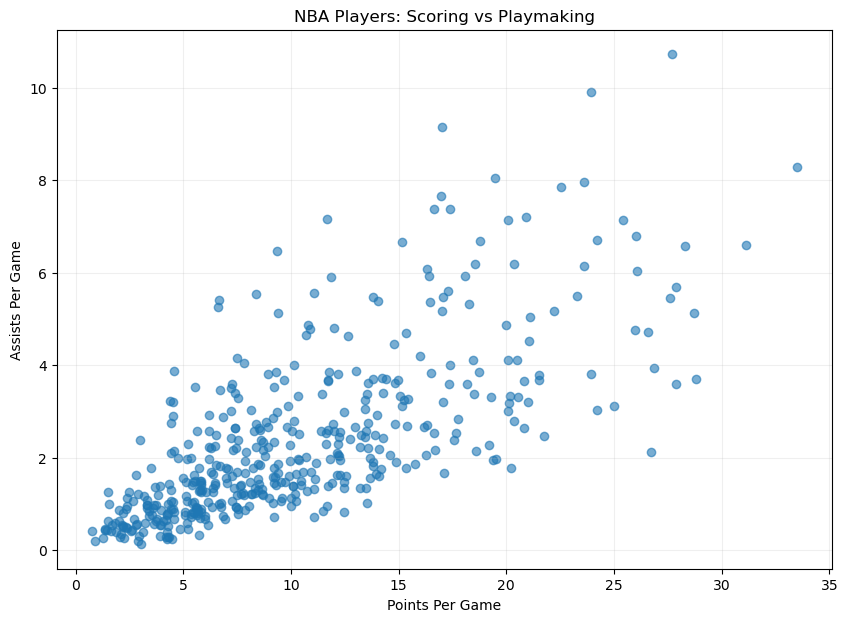

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    player_stats["PTS"],
    player_stats["AST"],
    alpha=0.6
)

plt.xlabel("Points Per Game")
plt.ylabel("Assists Per Game")
plt.title("NBA Players: Scoring vs Playmaking")

plt.grid(alpha=0.2)
plt.show()

In [54]:
features = [
    "REB",
    "AST",
    "STL",
    "BLK",
    "FG3A",
    "FGA",
    "FTA",
    "TOV"
]

correlation = player_stats[features].corr()

print(correlation.round(2))

       REB   AST   STL   BLK  FG3A   FGA   FTA   TOV
REB   1.00  0.35  0.39  0.66  0.09  0.52  0.57  0.52
AST   0.35  1.00  0.61  0.07  0.50  0.74  0.65  0.86
STL   0.39  0.61  1.00  0.21  0.45  0.61  0.47  0.60
BLK   0.66  0.07  0.21  1.00 -0.03  0.26  0.31  0.24
FG3A  0.09  0.50  0.45 -0.03  1.00  0.74  0.41  0.54
FGA   0.52  0.74  0.61  0.26  0.74  1.00  0.83  0.85
FTA   0.57  0.65  0.47  0.31  0.41  0.83  1.00  0.80
TOV   0.52  0.86  0.60  0.24  0.54  0.85  0.80  1.00


In [55]:
cluster_df = player_stats[
    player_stats["GP"] >= 20
].copy()

X = cluster_df[features]

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans 

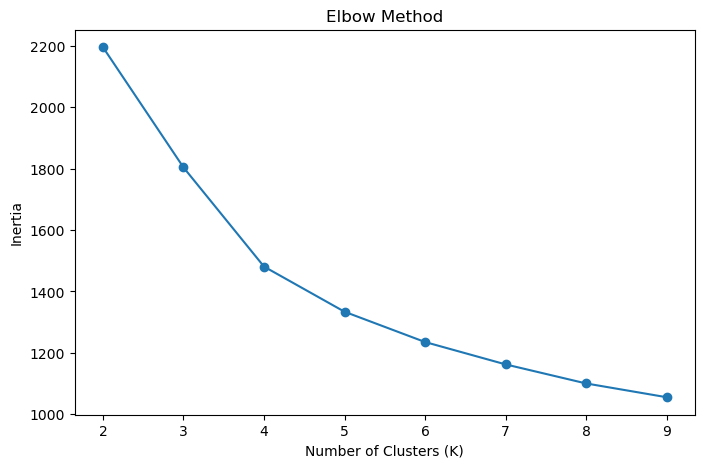

In [57]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

K_values = range(2, 10)

for k in K_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X_scaled)

    inertias.append(model.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(
    K_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [58]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 10):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f"K = {k}: {score:.3f}")

c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


K = 2: 0.378
K = 3: 0.255


c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


K = 4: 0.271
K = 5: 0.245


c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


K = 6: 0.248
K = 7: 0.220
K = 8: 0.219
K = 9: 0.233


c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


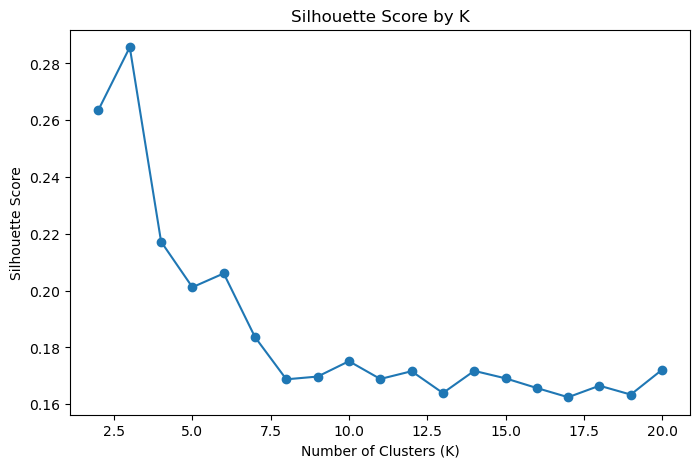

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 10),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")

plt.show()

In [61]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import pandas as pd

results = []

for n_init in [10, 20, 50, 100]:

    for max_iter in [300, 500, 1000]:

        model = KMeans(
            n_clusters=5,
            init="k-means++",
            n_init=n_init,
            max_iter=max_iter,
            random_state=42
        )

        labels = model.fit_predict(X_scaled)

        results.append({
            "n_init": n_init,
            "max_iter": max_iter,
            "silhouette": silhouette_score(
                X_scaled,
                labels
            ),
            "davies_bouldin": davies_bouldin_score(
                X_scaled,
                labels
            ),
            "calinski_harabasz": calinski_harabasz_score(
                X_scaled,
                labels
            ),
            "inertia": model.inertia_
        })

results_df = pd.DataFrame(results)

print(
    results_df.sort_values(
        "silhouette",
        ascending=False
    )
)

c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans 

    n_init  max_iter  silhouette  davies_bouldin  calinski_harabasz  \
3       20       300    0.245109        1.350286         191.201658   
4       20       500    0.245109        1.350286         191.201658   
5       20      1000    0.245109        1.350286         191.201658   
6       50       300    0.245109        1.350286         191.201658   
7       50       500    0.245109        1.350286         191.201658   
8       50      1000    0.245109        1.350286         191.201658   
9      100       300    0.245109        1.350286         191.201658   
10     100       500    0.245109        1.350286         191.201658   
11     100      1000    0.245109        1.350286         191.201658   
0       10       300    0.244268        1.356938         191.166513   
1       10       500    0.244268        1.356938         191.166513   
2       10      1000    0.244268        1.356938         191.166513   

        inertia  
3   1333.836568  
4   1333.836568  
5   1333.836568  
6   

In [59]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=3
)

cluster_df["CLUSTER"] = kmeans.fit_predict(X_scaled)

c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [60]:
cluster_summary = (
    cluster_df
    .groupby("CLUSTER")[features]
    .mean()
    .round(2)
)

print(cluster_summary)

          REB   AST   STL   BLK  FG3A    FGA   FTA   TOV
CLUSTER                                                 
0        4.18  3.72  1.04  0.40  5.27  12.02  3.02  1.86
1        3.12  2.16  0.78  0.29  3.75   7.10  1.39  1.04
2        6.44  5.89  1.18  0.54  5.54  16.88  6.29  2.84
3        2.22  0.90  0.38  0.23  1.49   3.34  0.76  0.52
4        7.00  1.87  0.77  1.12  2.02   8.22  2.55  1.30


In [80]:
# Guard vs Big macro axis
features["AST_to_REB"] = df["AST"] / (df["REB"] + 1e-5)

# PG vs SG distinction (Passing frequency relative to shot attempts)
features["AST_to_FGA"] = df["AST"] / (df["FGA"] + 1e-5)

# Perimeter vs Interior shot selection (SG/SF vs PF/C)
features["FG3_RATE"] = df["FG3A"] / (df["FGA"] + 1e-5)

# Frontcourt offensive positioning (PF/C vs SG/SF)
if "OREB" in df.columns:
    features["OREB_SHARE"] = df["OREB"] / (df["REB"] + 1e-5)

# Rim protection vs perimeter disruption
features["BLK_to_STL"] = df["BLK"] / (df["STL"] + 1e-5)

# Rebounding density
features["REB_PER_MIN"] = df["REB"] / (df["MIN"] + 1e-5) if "MIN" in df.columns else df["REB"]

# 2. Scale & Cluster

TypeError: list indices must be integers or slices, not str

In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = [
    "REB",
    "AST",
    "STL",
    "BLK",
    "FG3A",
    "FGA",
    "FTA",
    "TOV"
]

# Only players with enough games
cluster_df = player_stats[
    player_stats["GP"] >= 20
].copy()

# Select features
X = cluster_df[features]

# Standardize
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# K-Means
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    n_init=50,
    max_iter=500,
    random_state=42
)

# Fit
cluster_df["CLUSTER"] = kmeans.fit_predict(
    X_scaled
)

print(
    cluster_df[
        [
            "PLAYER_NAME",
            "CLUSTER"
        ]
    ]
)
cluster_df.loc[
    cluster_df["PLAYER_NAME"] == "Draymond Green",
    ["PLAYER_NAME", "CLUSTER"]
]

c:\Users\Anveetha Suresh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


            PLAYER_NAME  CLUSTER
0           A.J. Lawson        0
1              AJ Green        4
2            AJ Johnson        0
3          Aaron Gordon        1
4         Aaron Holiday        0
..                  ...      ...
574  Zaccharie Risacher        4
577         Zach LaVine        1
578          Zeke Nnaji        0
579     Ziaire Williams        4
580     Zion Williamson        3

[452 rows x 2 columns]


,PLAYER_NAME,CLUSTER
159,Draymond Green,1


In [78]:
cluster_df[
    ["PLAYER_NAME", "CLUSTER"]
].sort_values("CLUSTER")

,PLAYER_NAME,CLUSTER
0,A.J. Lawson,0
215,JD Davison,0
436,Noah Penda,0
219,Jabari Walker,0
224,Jae'Sean Tate,0
...,...,...
437,Nolan Traore,4
210,Isaiah Joe,4
441,Obi Toppin,4
430,Nikola Jović,4


In [79]:
cluster_df[
    cluster_df["CLUSTER"] == 3
][
    ["PLAYER_NAME", "CLUSTER"]
]

,PLAYER_NAME,CLUSTER
19,Alperen Sengun,3
21,Amen Thompson,3
31,Anthony Edwards,3
37,Austin Reaves,3
39,Bam Adebayo,3
71,Cade Cunningham,3
107,Cooper Flagg,3
139,Deni Avdija,3
146,Devin Booker,3
154,Donovan Mitchell,3


In [ ]:
position_labels = {
    0: "PG",
    1: "PG",
    2: "PF",
    3: "SF",
    4: "C"
}

cluster_df["PREDICTED_POSITION"] = (
    cluster_df["CLUSTER"]
    .map(position_labels)
)

cluster_df[
    [
        "PLAYER_NAME",
        "CLUSTER",
        "PREDICTED_POSITION"
    ]
].sort_values("PREDICTED_POSITION")

,PLAYER_NAME,CLUSTER,PREDICTED_POSITION
289,Jonathan Kuminga,4,C
136,Dean Wade,4,C
350,Kris Murray,4,C
349,Kris Dunn,4,C
346,Kobe Sanders,4,C
...,...,...,...
269,Jeremiah Fears,1,SG
402,Miles Bridges,1,SG
98,Coby White,1,SG
400,Mikal Bridges,1,SG
